# ___

# [ Machine Learning in Geosciences ]

## **ML Workflow exampl** 

*Author: lukas.brodsky@natur.cuni.cz*

@KAGIK

___


### 1.1 The Problem

TASK: Predict Forest Fires using Meteorological Data

Context: "Forest fires are a major environmental issue, creating economical and ecological damage while endangering human lives. Fast detection is a key element for controlling such phenomenon. To achieve this, one alternative is to use automatic tools based on local sensors, such as provided by meteorological stations. In effect, meteorological conditions (e.g. temperature, wind) are known to influence forest fires and several fire indexes, such as the forest Fire Weather Index (FWI), you can use such features, see below the figure for feature engineering. 
In this work, we explore a Machine Learning (ML) approach to **predict the burned area of forest fires**.

Published: P. Cortez, Aníbal de Jesus Raimundo Morais (2007):  New Trends in Artificial Intelligence, Proceedings of the 13th EPIA 2007 - Portuguese Conference on Artificial Intelligence

### 1.2 Assumptions

* The problem is a multivariate regression (will use multiple features to make a prediction); 
* There is no continuous flow of data, hence batch learning shall be applied; 
* The meterological data are good indicators of the forest fire; 
* There are enough variables (features) to predict the forest fire. 


### 1.3 Expected results 

* Machine Learning model to predict the burned area of the forest fires based on the meterological data. 

https://repositorium.uminho.pt/server/api/core/bitstreams/cd830a49-5053-4767-bdee-fcc169ae3c7d/content

Expected MAD (Median Absolute Deviation) is around 12 ha, based on Cortez e tal. (2007). 
___    

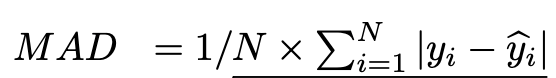

### Weather features

<div>
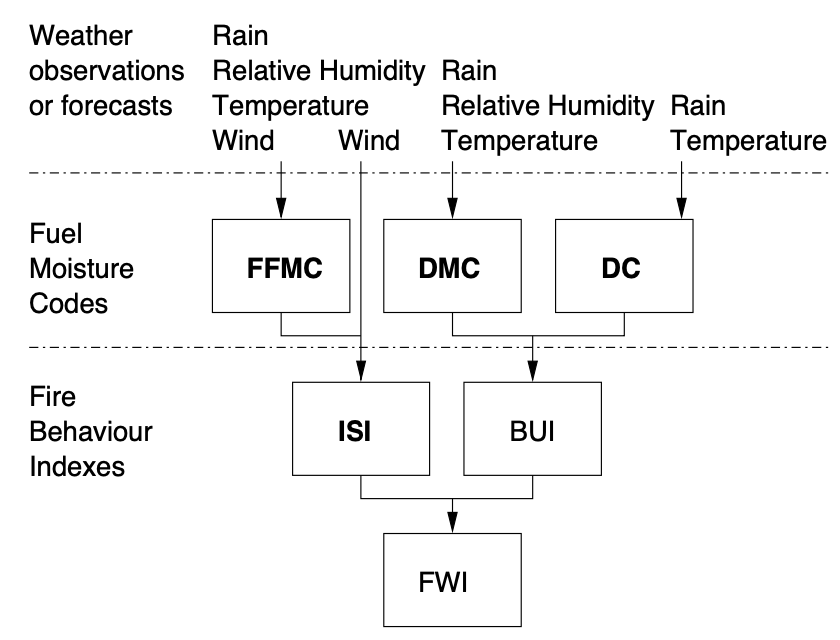
</div>

**Abreviations:**

* Fire Weather Index (FWI) 
* Fine Fuel Moisture Code (FFMC) 
* Duff Moisture Code (DMC)
* Drought Code (DC) 
* Initial Spread Index (ISI) 
* Buildup Index (BUI) 

### Input data atrributes description

**Attribute information**

   1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
   2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
   3. month - month of the year: "jan" to "dec" 
   4. day - day of the week: "mon" to "sun"
   5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
   6. DMC - DMC index from the FWI system: 1.1 to 291.3 
   7. DC - DC index from the FWI system: 7.9 to 860.6 
   8. ISI - ISI index from the FWI system: 0.0 to 56.10
   9. temp - temperature in Celsius degrees: 2.2 to 33.30
   10. RH - relative humidity in %: 15.0 to 100
   11. wind - wind speed in km/h: 0.40 to 9.40 
   12. rain - outside rain in mm/m2 : 0.0 to 6.4 
   13. area - the burned area of the forest (in ha): 0.00 to 1090.84 


#####  Problem definition checklist
    [x] What exactly is the target variable y?
    [x] What are the input features X? 
    [x] Is this classification, regression, or another task?
    [x] What is the unit of observation (pixel, polygon, time step)?
    [x] Is this prediction or explanation?
    [x] What assumptions am I making about the process?
    [?] What would a “good” prediction mean in this context?
    [Avoid] Is there spatial or temporal structure I must consider?


In [36]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
# Input data 
'./machine_learning_geosciences/06_ML_workflow/data/forestfires.csv'

'./machine_learning_geosciences/06_ML_workflow/data/forestfires.csv'

In [7]:
# Data import - pandas pd.read_csv()
file_path = './data/forestfires.csv'
df = pd.read_csv(file_path)
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### 2. Exploratory Data Analysis (EDA) 

In [90]:
import seaborn as sns

<Axes: xlabel='X', ylabel='Y'>

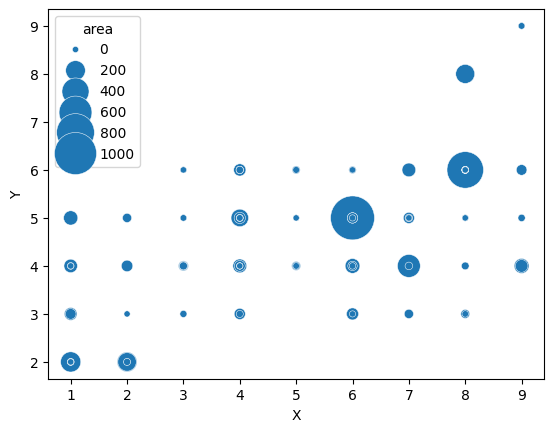

In [98]:
# plot burnt area - spatial plot
sns.scatterplot(
    data=df,
    x="X",
    y="Y",
    size="area",
    legend=True, 
    sizes=(20, 1000)
)

<Axes: >

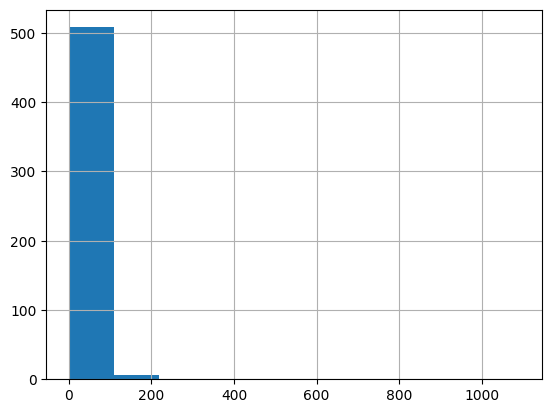

In [8]:
# hsit burned area np.hist plt.hist()
df['area'].hist()

<Axes: >

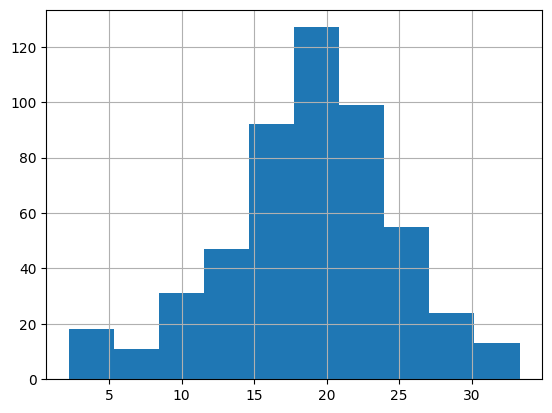

In [9]:
# hist of meteo data 
df['temp'].hist()

In [ ]:
# corr between features 


In [ ]:
# explore importance sat/sun days vs. fires 

##### EDA checklist 

    [] What is the distribution of each feature?
    [] Are there missing values? How many?
    [] Are there outliers or unrealistic values?
    [] Is the dataset balanced (for regression)? SMOGEN 
    [] Are features correlated or redundant?
    [] Are there different regimes or clusters in the data?
    [x] Does the data reflect real-world variability?
    [avoid] Are there spatial or temporal patterns? 


### 3. Data preparation 

### SMOGEN 
SMOGN (Synthetic Minority Over-sampling Technique for Regression with Gaussian Noise) is a Python library used to handle imbalanced datasets in regression problems, specifically when certain rare or extreme target values need to be predicted more accurately.

* Imbalanced Regression: Addresses datasets where the target variable has rare extreme values.
* SMOGN Algorithm: Uses KNN distances to determine whether to apply traditional SMOTER (interpolation) or introduce Gaussian Noise (SMOTER-GN).
* Flexibility: Allows control over which areas of the continuous target variable are considered "rare" and need over-sampling.


In [2]:
# SMOGEN
# !pip3 install smogn

In [23]:
import smogn 

In [68]:
# 2. Apply SMOGN
# 'y' is the target column
# 'k' is the number of neighbors
df_smogn = smogn.smoter(
    data = df, 
    y = 'area',
    k = 3,
    samp_method = 'extreme' # 'balance' # or 'extreme'
)

r_index: 100%|#################################| 85/85 [00:00<00:00, 246.54it/s]


In [69]:
df_smogn.shape

(693, 13)

<Axes: >

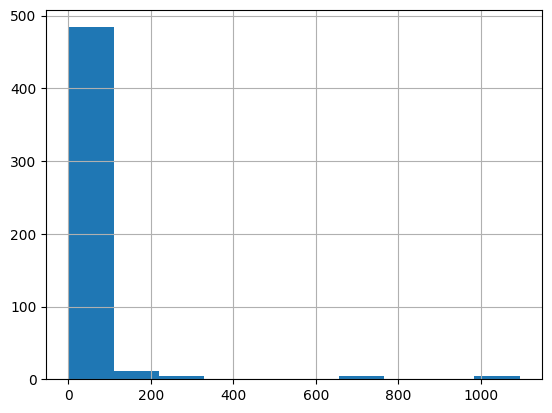

In [70]:
df_smogn[df_smogn['area'] > 1]['area'].hist()

<Axes: >

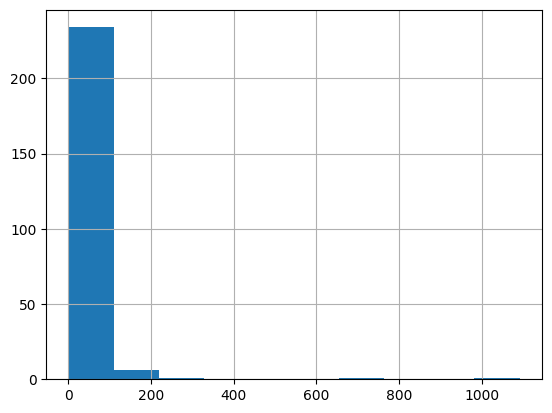

In [71]:
df[df['area'] > 1]['area'].hist()

In [72]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


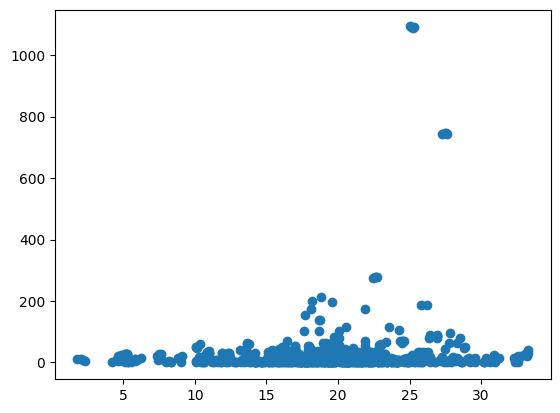

In [73]:
plt.scatter(df_smogn['temp'], df_smogn['area'])

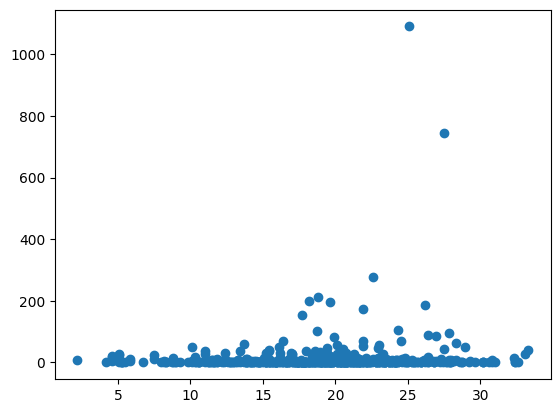

In [74]:
plt.scatter(df['temp'], df['area'])

### Do not use SMOGEN, no improvemnt. 

<Axes: >

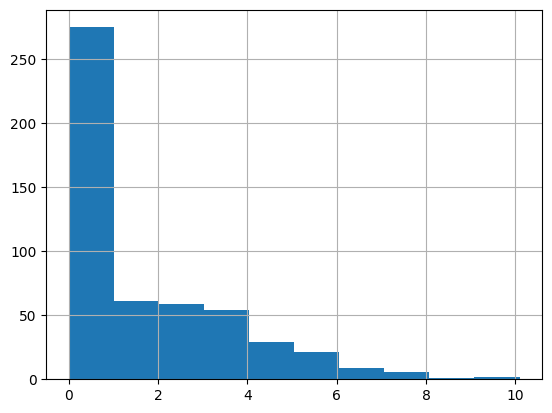

In [94]:
# many 0, some areas > 0 up to 10000 ha 
# logarithm transform 
# df['area'].hist()
df['area_ln'] = np.log2(df['area'] + 1)
df['area_ln'].hist()

<Axes: >

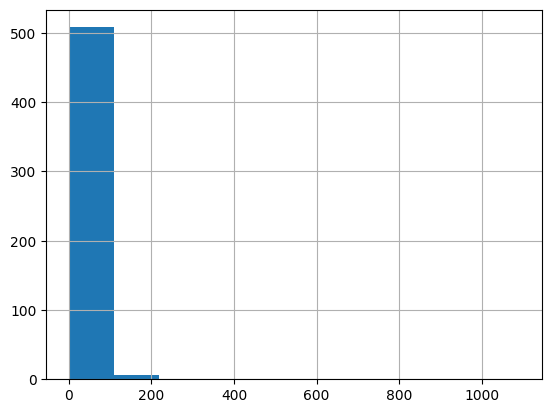

In [22]:
df['area'].hist()

In [ ]:
# cat values to numerical 

In [ ]:
# split: stratified must! 

In [ ]:
# scale! 

#####  Data Preparation chacklist

    [] Did I split the data before preprocessing?
    [] Is there any data leakage (future info, target leakage)?
    [] Are features scaled/normalized appropriately?
    [] How are missing values handled?
    [] Are categorical variables encoded correctly?
    [] Did I remove irrelevant or redundant features?
    [] Is class imbalance addressed (if needed)?
    [] Is preprocessing reproducible (pipeline)?


### 4. Select and train model 

In [ ]:
# non-linear problem BUT I will start with simple multi-variate linear model as baseline

In [ ]:
# next: SVM, Tree-based regresion model 

In [ ]:
pass

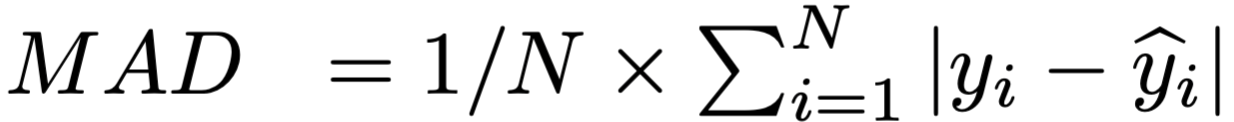

In [83]:
# define MAD 
def MAD(y, y_hat):
    return (1/y.size) * (np.sum(np.abs(y-y_hat)))

#####  Data Preparation checklist

    [] What assumption does this model make?
    [] Does the data satisfy this assumption?
    [] Is the model too simple (underfitting risk)?
    [] Is the model too complex (overfitting risk)?
    [] How sensitive is the model to noise?
    [avoid] Does the model handle spatial/temporal structure?
    [] Is the model interpretable if needed?
    [] Am I comparing multiple models or guessing one?


### 5. Model fine-tuning & validation 

In [ ]:
# RandomizedSearch on limited models: A/ SVR and B/ RF 
# validation 

In [ ]:
# CV folds: 3, 5-10 

In [ ]:
# sensitivity through splits 

In [ ]:
# MAE 

In [3]:
# Median Absolute Deviation (MAD) 
# robust measure of statistical dispersion, representing the median of the absolute deviations 
# from the data's median


###### Model-finetuning & validation checklist

    [] Is my validation strategy appropriate (CV, spatial CV)?
    [] Is the test set truly unseen?
    [] Am I tuning hyperparameters on validation (not test)?
    [] Are results stable across different splits?
    [] What metric am I optimizing?
    [] Does the metric reflect the real objective?
    [] Am I overfitting during tuning?
    [] Is model performance consistent?


### 6. Results interpretation


In [ ]:
pass 

In [ ]:
pass

In [ ]:
pass 

##### Results interpretation checklist

    [] How good is the model? (metrics)
    [] Where does it fail? (error structure)
    [] Why does it fail? (bias/variance, data)
    [] Does it make sense scientifically?
    [] Can we trust it in real-world use? 
